In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import joblib

DATA_DIR = Path.home() / "kkbox-churn" / "data" / "parquet"
MODEL_DIR = Path.home() / "kkbox-churn" / "models"

master = pd.read_parquet(DATA_DIR / "master_dataset.parquet")

drop_cols = [
    'msno', 'last_transaction_date', 'last_expire_date',
    'last_listen_date', 'first_listen_date',
    'cluster_k5', 'segment',
    'churn_prob', 'monthly_revenue', 'churn_prob_clipped',
    'clv', 'retention_priority'
]
master = master.drop(columns=[c for c in drop_cols if c in master.columns])

for col in ['city', 'registered_via', 'bd_bucket', 'auto_renew_switch']:
    master[col] = master[col].astype('category')

master_raw = pd.read_parquet(DATA_DIR / "master_dataset.parquet")
may_idx = master_raw[master_raw['last_expire_date'].dt.to_period('M') == '2017-05'].index

X = master.drop(columns=['is_churn'])
y = master['is_churn']
X_val, y_val = X.loc[may_idx], y.loc[may_idx]

final_model = joblib.load(MODEL_DIR / "lgbm_churn_final.pkl")
print(f"Val shape: {X_val.shape}")
print(f"Model loaded: {final_model.best_iteration_} iterations")

Val shape: (79942, 101)
Model loaded: 185 iterations


Computing SHAP values...


/opt/anaconda3/envs/kkbox/lib/python3.11/site-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


SHAP values shape: (5000, 101)


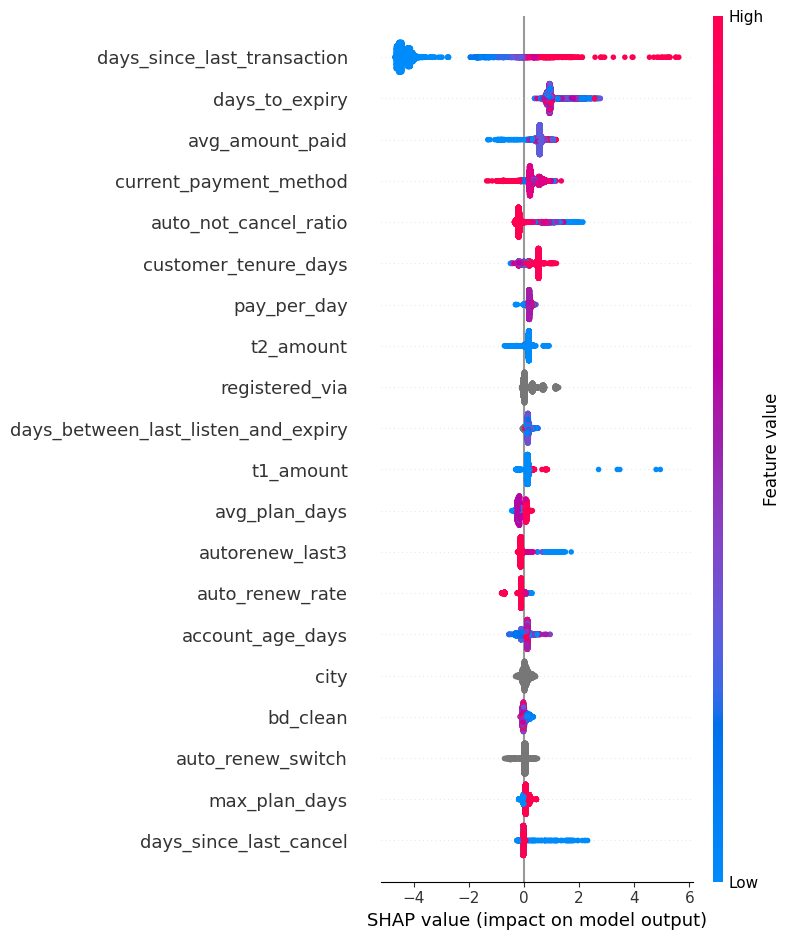

Saved: shap_summary.png


In [5]:
# Cell 2 — SHAP values
explainer = shap.TreeExplainer(final_model)

# Sample 5000 from val set for speed
X_shap = X_val.sample(5000, random_state=42)

print("Computing SHAP values...")
shap_values = explainer.shap_values(X_shap)

print(f"SHAP values shape: {shap_values.shape}")

# Summary plot
plt.figure()
shap.summary_plot(shap_values, X_shap, max_display=20, show=False)
plt.tight_layout()
plt.savefig(MODEL_DIR / "shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary.png")

In [6]:
# Cell 3 — Save SHAP values
shap_vals = shap_values[1] if isinstance(shap_values, list) else shap_values

shap_df = pd.DataFrame(
    shap_vals,
    columns=X_shap.columns,
    index=X_shap.index
)
shap_df.to_parquet(DATA_DIR / "shap_values.parquet")
print(f"SHAP values saved: {shap_df.shape}")

# Top 20 mean absolute SHAP
mean_shap = shap_df.abs().mean().sort_values(ascending=False)
print(f"\nTop 20 features by mean |SHAP|:")
print(mean_shap.head(20).to_string())

SHAP values saved: (5000, 101)

Top 20 features by mean |SHAP|:
days_since_last_transaction            3.850265
days_to_expiry                         1.019281
avg_amount_paid                        0.574359
current_payment_method                 0.372086
auto_not_cancel_ratio                  0.356515
customer_tenure_days                   0.312394
pay_per_day                            0.199653
t2_amount                              0.166080
registered_via                         0.157535
days_between_last_listen_and_expiry    0.149751
t1_amount                              0.148931
avg_plan_days                          0.146051
autorenew_last3                        0.145247
auto_renew_rate                        0.138408
account_age_days                       0.123810
city                                   0.079937
bd_clean                               0.074981
auto_renew_switch                      0.072128
max_plan_days                          0.062720
days_since_last_cancel  

In [7]:
# Cell 4 — Load SHAP values + add churn probabilities
shap_df = pd.read_parquet(DATA_DIR / "shap_values.parquet")

# Add churn predictions to X_shap
from sklearn.metrics import roc_auc_score
val_preds_shap = final_model.predict_proba(X_shap)[:, 1]
X_shap_copy = X_shap.copy()
X_shap_copy['churn_prob'] = val_preds_shap
X_shap_copy['actual'] = y_val.loc[X_shap.index]

print(f"High risk users (prob > 0.7): {(X_shap_copy['churn_prob'] > 0.7).sum():,}")
print(f"Low risk users (prob < 0.1):  {(X_shap_copy['churn_prob'] < 0.1).sum():,}")
print(f"\nSample high risk user:\n{X_shap_copy[X_shap_copy['churn_prob'] > 0.7].head(1)[['churn_prob','actual']].to_string()}")

High risk users (prob > 0.7): 171
Low risk users (prob < 0.1):  4,463

Sample high risk user:
      churn_prob  actual
6937     0.99491       1


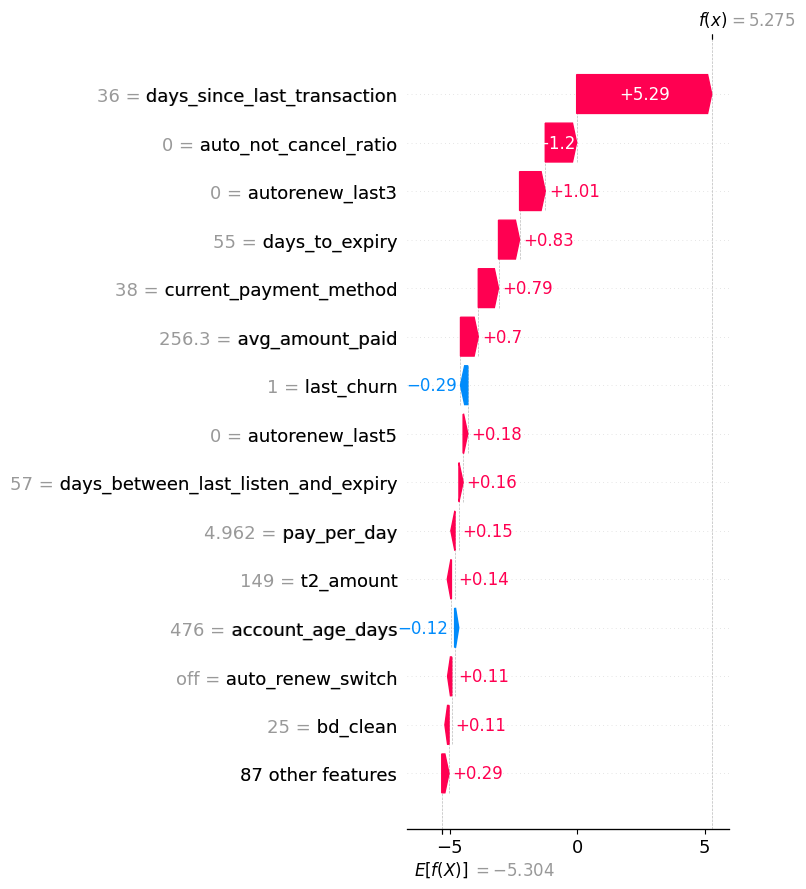

User churn probability: 0.9949
Actual churn: 1


In [8]:
# Get index of highest risk user
high_risk_idx = X_shap_copy[X_shap_copy['churn_prob'] > 0.7].index[0]
user_position = list(X_shap.index).index(high_risk_idx)

# Rebuild explainer object for waterfall
shap_vals_array = shap_values[1] if isinstance(shap_values, list) else shap_values

explanation = shap.Explanation(
    values=shap_vals_array[user_position],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    data=X_shap.iloc[user_position].values,
    feature_names=list(X_shap.columns)
)

plt.figure()
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.tight_layout()
plt.savefig(MODEL_DIR / "shap_waterfall_highrisk.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"User churn probability: {X_shap_copy.loc[high_risk_idx, 'churn_prob']:.4f}")
print(f"Actual churn: {X_shap_copy.loc[high_risk_idx, 'actual']}")

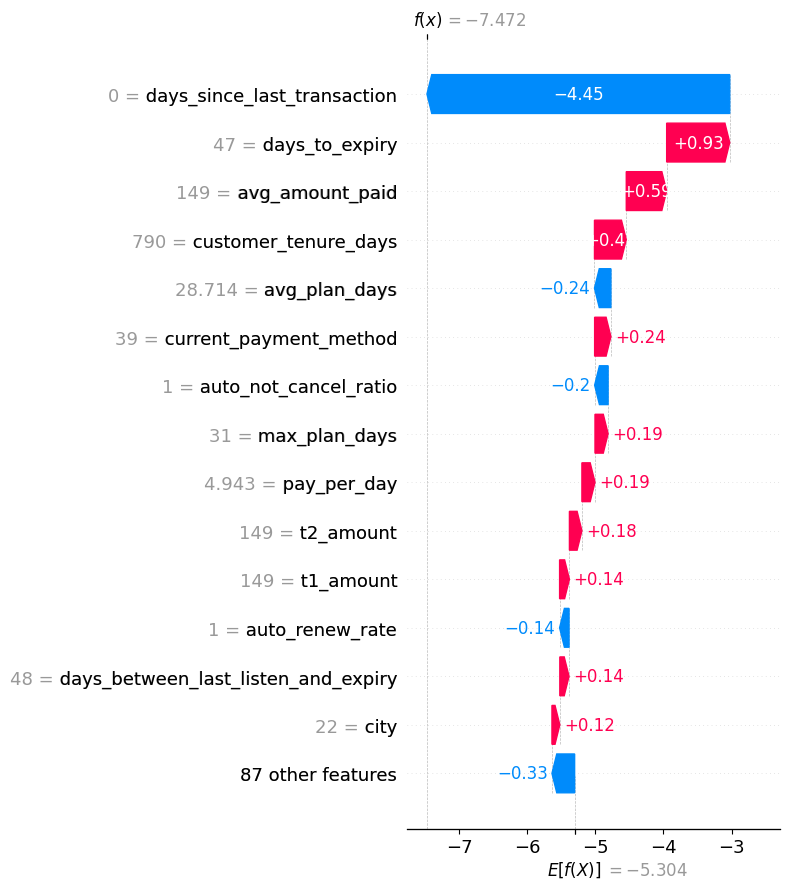

User churn probability: 0.0006
Actual churn: 0


In [9]:
# Cell 6 — Waterfall plot (single low risk user)
low_risk_idx = X_shap_copy[X_shap_copy['churn_prob'] < 0.05].index[0]
user_position_low = list(X_shap.index).index(low_risk_idx)

explanation_low = shap.Explanation(
    values=shap_vals_array[user_position_low],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    data=X_shap.iloc[user_position_low].values,
    feature_names=list(X_shap.columns)
)

plt.figure()
shap.plots.waterfall(explanation_low, max_display=15, show=False)
plt.tight_layout()
plt.savefig(MODEL_DIR / "shap_waterfall_lowrisk.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"User churn probability: {X_shap_copy.loc[low_risk_idx, 'churn_prob']:.4f}")
print(f"Actual churn: {X_shap_copy.loc[low_risk_idx, 'actual']}")